# Two-Stage Model: Dedicated Fatality Detector + Injury Classifier

**Why two stages instead of one 3-class model:**

The multi-class XGBoost spends ~60% of its capacity separating No Injury from Injury and only ~40% on the Fatality boundary. A specialist detector puts 100% of its capacity on catching fatalities.

**Stage 1 — Binary XGBoost: Fatality vs. Not-Fatality**
- Uses `scale_pos_weight ≈ 363` (exact inverse-frequency ratio for binary)
- This is the precise tool XGBoost was designed for — far more principled than the 3× manual boost
- Threshold tuned independently to maximize Fatality recall

**Stage 2 — Binary XGBoost: No Injury vs. Injury**
- Trained only on non-fatality crashes (the cases Stage 1 passes through)
- These classes are nearly balanced (59% / 41%), standard settings work

**Final prediction:** Stage 1 output takes precedence. If Stage 1 flags Fatality, done. Otherwise Stage 2 decides No Injury vs. Injury.

---
## 1. Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, roc_auc_score,
    precision_recall_curve
)

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42
CLASS_NAMES  = ['No Injury', 'Injury', 'Fatality']
print(f'XGBoost {xgb.__version__}')

XGBoost 1.7.6


---
## 2. Load and inspect data

In [2]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
for cls, name in enumerate(CLASS_NAMES):
    n = (df['severity'] == cls).sum()
    print(f'  {name:12s}: {n:>7,}  ({n/len(df)*100:.2f}%)')

Shape: 394,751 rows x 29 columns
  No Injury   : 230,535  (58.40%)
  Injury      : 163,164  (41.33%)
  Fatality    :   1,052  (0.27%)


---
## 3. Feature engineering

Identical to the XGBoost notebook — same feature set for a fair comparison.

In [3]:
df = df.copy()

def month_to_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'fall'

def hour_to_period(h):
    if h < 5:  return 'late_night'
    if h < 10: return 'morning'
    if h < 15: return 'midday'
    if h < 19: return 'evening'
    return 'night'

df['season']      = df['month'].apply(month_to_season)
df['time_of_day'] = df['hour'].apply(hour_to_period)

vt = ['vehicle_type_1', 'vehicle_type_2']
df['bike_involved']       = df[vt].isin(['BIKE','E-BIKE','E-SCOOTER']).any(axis=1).astype(int)
df['motorcycle_involved'] = df[vt].isin(['MOTORCYCLE','MOPED']).any(axis=1).astype(int)
df['unknown_factor']      = df[['factor_vehicle_1','factor_vehicle_2']].isin(['UNSPECIFIED','UNKNOWN']).any(axis=1).astype(int)

TRUCK_LABELS = ['TRUCK','BOX TRUCK','TRACTOR TRUCK DIESEL','TRACTOR TRUCK GASOLINE',
                'FLAT BED','GARBAGE OR REFUSE','DUMP','TANKER','CONCRETE MIXER']
df['truck_involved'] = df[vt].isin(TRUCK_LABELS).any(axis=1).astype(int)
df['num_vehicles']   = df['vehicle_type_1'].notna().astype(int) + df['vehicle_type_2'].notna().astype(int)

dark = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['bike_dark']  = df['bike_involved'] * dark
df['moto_rush']  = df['motorcycle_involved'] * df['is_rush_hour']

df['lat_bin']   = pd.qcut(df['latitude'],  q=5, labels=['lat0','lat1','lat2','lat3','lat4'], duplicates='drop')
df['lon_bin']   = pd.qcut(df['longitude'], q=5, labels=['lon0','lon1','lon2','lon3','lon4'], duplicates='drop')
df['grid_cell'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

print('Feature engineering done.')

Feature engineering done.


---
## 4. Define features and split

In [4]:
DROP_COLS = [
    'severity','num_injured','num_killed',
    'number_of_pedestrians_injured','number_of_pedestrians_killed',
    'number_of_cyclist_injured','number_of_cyclist_killed',
    'number_of_motorist_injured','number_of_motorist_killed',
    'collision_id','crash_date','crash_time',
    'on_street_name','cross_street_name','location',
    'zip_code','year','latitude','longitude','lat_bin','lon_bin',
]
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].copy()
y = df['severity'].copy()

train_mask = df['year'].isin([2022, 2023, 2024])
test_mask  = df['year'] == 2025
X_train_raw, y_train = X[train_mask].copy(), y[train_mask].copy()
X_test_raw,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

print(f'Train: {len(X_train_raw):,}   Test: {len(X_test_raw):,}')
for cls, name in enumerate(CLASS_NAMES):
    n = (y_train == cls).sum()
    print(f'  Train {name}: {n:,} ({n/len(y_train)*100:.2f}%)')

Train: 291,808   Test: 85,534
  Train No Injury: 171,772 (58.86%)
  Train Injury: 119,235 (40.86%)
  Train Fatality: 801 (0.27%)


---
## 5. Preprocess categorical features

In [5]:
def cap_top_n(series, n=12):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), 'OTHER')

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

for col in ['vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']:
    if col in X_train.columns:
        X_train[col] = cap_top_n(X_train[col])
        X_test[col]  = X_test[col].where(X_test[col].isin(X_train[col].unique()), 'OTHER')

CAT_COLS = ['borough','day_of_week','season','time_of_day','grid_cell',
            'vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]

X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

for df_ in [X_train, X_test]:
    for col in df_.select_dtypes(include='category').columns:
        df_[col] = df_[col].astype(float)

X_train = X_train.fillna(0).astype(float)
X_test  = X_test.fillna(0).astype(float)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')

X_train: (291808, 101)   X_test: (85534, 101)


---
## 6. Stage 1 — Fatality vs. Not-Fatality

`scale_pos_weight` = count(negatives) / count(positives) tells XGBoost to treat each Fatality sample as if it were ~363 non-fatality samples in the loss function. This is the native, principled way to handle binary imbalance — no synthetic data, no manual tuning of a multiplier.

In [6]:
# Binary labels: 1 = Fatality, 0 = Not-Fatality
y_train_s1 = (y_train == 2).astype(int)
y_test_s1  = (y_test  == 2).astype(int)

n_neg = (y_train_s1 == 0).sum()
n_pos = (y_train_s1 == 1).sum()
spw   = n_neg / n_pos

print(f'Stage 1 training set:')
print(f'  Not-Fatality: {n_neg:,}')
print(f'  Fatality:     {n_pos:,}')
print(f'  scale_pos_weight: {spw:.1f}')

S1_PARAMS = dict(
    objective='binary:logistic',
    scale_pos_weight=spw,
    n_estimators=150,        # kept lower for speed; final model uses 300
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

Stage 1 training set:
  Not-Fatality: 291,007
  Fatality:     801
  scale_pos_weight: 363.3


### 6a. Cross-validate Stage 1

In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
s1_recalls, s1_precisions, s1_aucs = [], [], []

for tr_idx, val_idx in cv.split(X_train, y_train_s1):
    X_tr, y_tr   = X_train.iloc[tr_idx], y_train_s1.iloc[tr_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train_s1.iloc[val_idx]

    m = xgb.XGBClassifier(**S1_PARAMS)
    m.fit(X_tr, y_tr, verbose=False)

    proba = m.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    s1_recalls.append(recall_score(y_val, pred, zero_division=0))
    s1_precisions.append(precision_score(y_val, pred, zero_division=0))
    s1_aucs.append(roc_auc_score(y_val, proba))

print('Stage 1 cross-validation (Fatality vs. Not-Fatality):')
print(f'  Fatality recall:    {np.mean(s1_recalls):.4f} ± {np.std(s1_recalls):.4f}')
print(f'  Fatality precision: {np.mean(s1_precisions):.4f} ± {np.std(s1_precisions):.4f}')
print(f'  ROC-AUC:            {np.mean(s1_aucs):.4f} ± {np.std(s1_aucs):.4f}')

Stage 1 cross-validation (Fatality vs. Not-Fatality):
  Fatality recall:    0.6280 ± 0.0168
  Fatality precision: 0.0130 ± 0.0002
  ROC-AUC:            0.8364 ± 0.0095


### 6b. Train final Stage 1 model and tune threshold

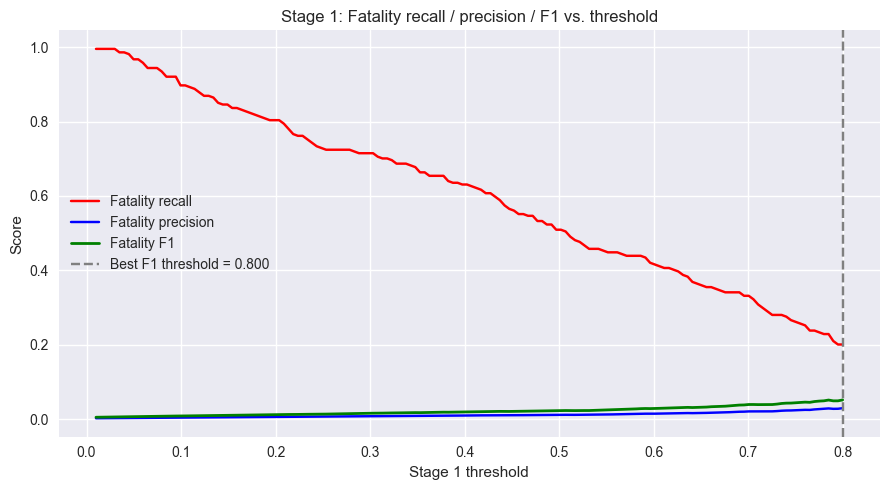

Best Stage 1 threshold: 0.8000
  Fatality recall:    0.2009
  Fatality precision: 0.0298
  Fatality F1:        0.0519
  ROC-AUC (test):     0.8223


In [8]:
s1_final_params = {**S1_PARAMS, 'n_estimators': 300}
stage1 = xgb.XGBClassifier(**s1_final_params)
stage1.fit(X_train, y_train_s1, verbose=False)

s1_proba = stage1.predict_proba(X_test)[:, 1]  # P(Fatality) for each test crash

# Threshold sweep: maximize Fatality F1
thresholds = np.linspace(0.01, 0.80, 160)
s1_rec, s1_prec, s1_f1 = [], [], []
for t in thresholds:
    pred = (s1_proba >= t).astype(int)
    s1_rec.append(recall_score(y_test_s1, pred, zero_division=0))
    s1_prec.append(precision_score(y_test_s1, pred, zero_division=0))
    s1_f1.append(f1_score(y_test_s1, pred, zero_division=0))

s1_rec, s1_prec, s1_f1 = np.array(s1_rec), np.array(s1_prec), np.array(s1_f1)
best_s1_idx    = np.argmax(s1_f1)
best_s1_thresh = thresholds[best_s1_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, s1_rec,  label='Fatality recall',    color='red')
ax.plot(thresholds, s1_prec, label='Fatality precision', color='blue')
ax.plot(thresholds, s1_f1,   label='Fatality F1',        color='green', linewidth=2)
ax.axvline(best_s1_thresh, linestyle='--', color='gray',
           label=f'Best F1 threshold = {best_s1_thresh:.3f}')
ax.set_xlabel('Stage 1 threshold'); ax.set_ylabel('Score')
ax.set_title('Stage 1: Fatality recall / precision / F1 vs. threshold')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

print(f'Best Stage 1 threshold: {best_s1_thresh:.4f}')
print(f'  Fatality recall:    {s1_rec[best_s1_idx]:.4f}')
print(f'  Fatality precision: {s1_prec[best_s1_idx]:.4f}')
print(f'  Fatality F1:        {s1_f1[best_s1_idx]:.4f}')
print(f'  ROC-AUC (test):     {roc_auc_score(y_test_s1, s1_proba):.4f}')

---
## 7. Stage 2 — No Injury vs. Injury

Train only on non-fatality crashes. The classes are nearly balanced (59% / 41%) so no special weighting needed.

In [9]:
# Filter to non-fatality training samples only
nonfatal_mask_train = y_train != 2
X_train_s2 = X_train[nonfatal_mask_train]
y_train_s2 = y_train[nonfatal_mask_train].reset_index(drop=True)  # values: 0 or 1

n0 = (y_train_s2 == 0).sum()
n1 = (y_train_s2 == 1).sum()
print(f'Stage 2 training set:')
print(f'  No Injury: {n0:,} ({n0/(n0+n1)*100:.1f}%)')
print(f'  Injury:    {n1:,} ({n1/(n0+n1)*100:.1f}%)')

S2_PARAMS = dict(
    objective='binary:logistic',
    scale_pos_weight=n0/n1,   # slight adjustment for mild imbalance
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

Stage 2 training set:
  No Injury: 171,772 (59.0%)
  Injury:    119,235 (41.0%)


### 7a. Cross-validate Stage 2

In [10]:
s2_recalls, s2_precisions, s2_aucs = [], [], []

for tr_idx, val_idx in cv.split(X_train_s2, y_train_s2):
    X_tr, y_tr   = X_train_s2.iloc[tr_idx], y_train_s2.iloc[tr_idx]
    X_val, y_val = X_train_s2.iloc[val_idx], y_train_s2.iloc[val_idx]

    m = xgb.XGBClassifier(**S2_PARAMS)
    m.fit(X_tr, y_tr, verbose=False)

    proba = m.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    s2_recalls.append(recall_score(y_val, pred, zero_division=0))
    s2_precisions.append(precision_score(y_val, pred, zero_division=0))
    s2_aucs.append(roc_auc_score(y_val, proba))

print('Stage 2 cross-validation (No Injury vs. Injury):')
print(f'  Injury recall:    {np.mean(s2_recalls):.4f} ± {np.std(s2_recalls):.4f}')
print(f'  Injury precision: {np.mean(s2_precisions):.4f} ± {np.std(s2_precisions):.4f}')
print(f'  ROC-AUC:          {np.mean(s2_aucs):.4f} ± {np.std(s2_aucs):.4f}')

Stage 2 cross-validation (No Injury vs. Injury):
  Injury recall:    0.6061 ± 0.0025
  Injury precision: 0.6730 ± 0.0021
  ROC-AUC:          0.7789 ± 0.0005


### 7b. Train final Stage 2 model

In [11]:
s2_final_params = {**S2_PARAMS, 'n_estimators': 300}
stage2 = xgb.XGBClassifier(**s2_final_params)
stage2.fit(X_train_s2, y_train_s2, verbose=False)
print('Stage 2 training complete.')

Stage 2 training complete.


---
## 8. Combine stages and evaluate

Stage 1 has priority. If P(Fatality) ≥ threshold → predict Fatality.  
Otherwise, Stage 2 decides No Injury vs. Injury.

In [12]:
def combine_stages(s1_proba, stage2_model, X_test, s1_thresh):
    s1_pred    = (s1_proba >= s1_thresh).astype(int)  # 1=Fatality, 0=not
    s2_proba   = stage2_model.predict_proba(X_test)[:, 1]  # P(Injury)
    s2_pred    = (s2_proba >= 0.5).astype(int)  # 0=No Injury, 1=Injury
    final_pred = np.where(s1_pred == 1, 2, s2_pred)  # 2=Fatality, 1=Injury, 0=No Injury
    return final_pred

y_pred_best_f1 = combine_stages(s1_proba, stage2, X_test, best_s1_thresh)

print(f'=== Two-Stage Model (Stage 1 threshold = {best_s1_thresh:.4f}) ===')
print(classification_report(y_test, y_pred_best_f1, target_names=CLASS_NAMES))
print(f"Macro F1:        {f1_score(y_test, y_pred_best_f1, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_best_f1, labels=[2], average='macro', zero_division=0):.4f}")
print(f"Injury recall:   {recall_score(y_test, y_pred_best_f1, labels=[1], average='macro', zero_division=0):.4f}")

=== Two-Stage Model (Stage 1 threshold = 0.8000) ===
              precision    recall  f1-score   support

   No Injury       0.72      0.78      0.75     48121
      Injury       0.69      0.59      0.64     37199
    Fatality       0.03      0.20      0.05       214

    accuracy                           0.70     85534
   macro avg       0.48      0.53      0.48     85534
weighted avg       0.71      0.70      0.70     85534

Macro F1:        0.4803
Fatality recall: 0.2009
Injury recall:   0.5912


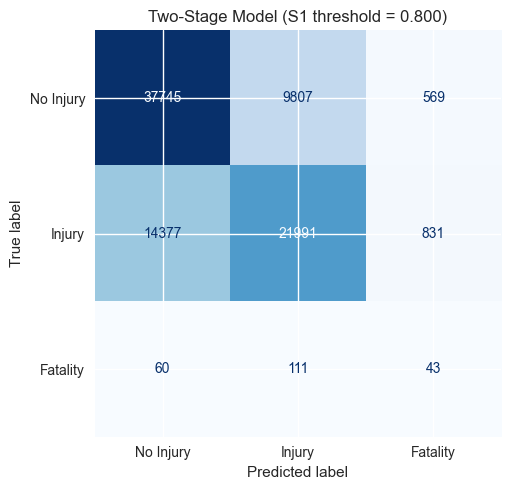

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best_f1),
                       display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Two-Stage Model (S1 threshold = {best_s1_thresh:.3f})')
plt.tight_layout(); plt.show()

---
## 9. Explore the recall / precision tradeoff across Stage 1 thresholds

The two-stage design lets us tune Stage 1's threshold independently. Here we show the full tradeoff — useful for choosing the operating point depending on whether the model is used as a screening tool (high recall, accept false positives) or a prioritization tool (balanced).

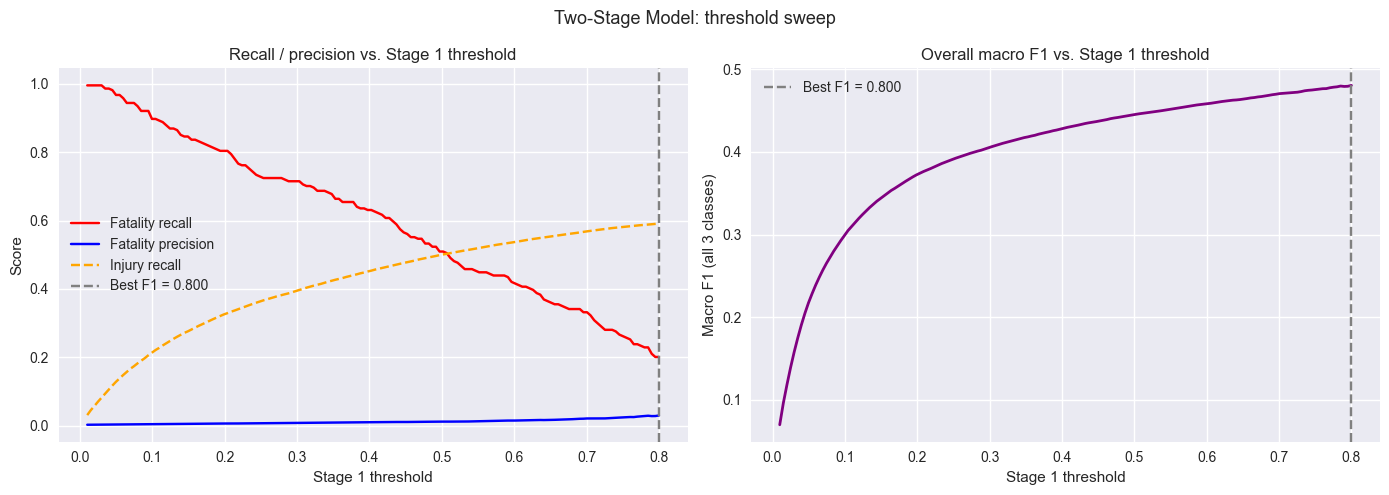

High-recall operating point (≥75% Fatality recall): threshold = 0.0100
  Fatality recall:    0.9953
  Fatality precision: 0.0027
  Macro F1:           0.0700


In [14]:
sweep_thresholds = np.linspace(0.01, 0.80, 160)
comb_macro_f1, comb_fat_rec, comb_fat_prec, comb_inj_rec = [], [], [], []

for t in sweep_thresholds:
    y_pred_t = combine_stages(s1_proba, stage2, X_test, t)
    comb_macro_f1.append(f1_score(y_test, y_pred_t, average='macro', zero_division=0))
    comb_fat_rec.append(recall_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    comb_fat_prec.append(precision_score(y_test, y_pred_t, labels=[2], average='macro', zero_division=0))
    comb_inj_rec.append(recall_score(y_test, y_pred_t, labels=[1], average='macro', zero_division=0))

comb_macro_f1 = np.array(comb_macro_f1)
comb_fat_rec  = np.array(comb_fat_rec)
comb_fat_prec = np.array(comb_fat_prec)
comb_inj_rec  = np.array(comb_inj_rec)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(sweep_thresholds, comb_fat_rec,  label='Fatality recall',    color='red')
ax.plot(sweep_thresholds, comb_fat_prec, label='Fatality precision', color='blue')
ax.plot(sweep_thresholds, comb_inj_rec,  label='Injury recall',      color='orange', linestyle='--')
ax.axvline(best_s1_thresh, linestyle='--', color='gray', label=f'Best F1 = {best_s1_thresh:.3f}')
ax.set_xlabel('Stage 1 threshold'); ax.set_ylabel('Score')
ax.set_title('Recall / precision vs. Stage 1 threshold')
ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(sweep_thresholds, comb_macro_f1, color='purple', linewidth=2)
ax.axvline(best_s1_thresh, linestyle='--', color='gray', label=f'Best F1 = {best_s1_thresh:.3f}')
ax.set_xlabel('Stage 1 threshold'); ax.set_ylabel('Macro F1 (all 3 classes)')
ax.set_title('Overall macro F1 vs. Stage 1 threshold')
ax.legend(); ax.grid(True)

plt.suptitle('Two-Stage Model: threshold sweep', fontsize=13)
plt.tight_layout(); plt.show()

# also report what a high-recall operating point looks like
hi_recall_idx  = np.argmax(comb_fat_rec >= 0.75)  # first threshold hitting 75% recall
hi_recall_thresh = sweep_thresholds[hi_recall_idx] if comb_fat_rec[hi_recall_idx] >= 0.75 else None
if hi_recall_thresh:
    print(f'High-recall operating point (≥75% Fatality recall): threshold = {hi_recall_thresh:.4f}')
    print(f'  Fatality recall:    {comb_fat_rec[hi_recall_idx]:.4f}')
    print(f'  Fatality precision: {comb_fat_prec[hi_recall_idx]:.4f}')
    print(f'  Macro F1:           {comb_macro_f1[hi_recall_idx]:.4f}')
else:
    print('Model does not reach 75% Fatality recall at any threshold — report max instead:')
    max_idx = np.argmax(comb_fat_rec)
    print(f'  Max Fatality recall: {comb_fat_rec[max_idx]:.4f} at threshold {sweep_thresholds[max_idx]:.4f}')

---
## 10. Full model comparison

In [15]:
# high-recall variant for the table
if hi_recall_thresh:
    y_pred_hirecall = combine_stages(s1_proba, stage2, X_test, hi_recall_thresh)
else:
    max_idx = np.argmax(comb_fat_rec)
    y_pred_hirecall = combine_stages(s1_proba, stage2, X_test, sweep_thresholds[max_idx])

summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)',    'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'Random Forest v1',                  'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'RF cleaner model',                  'Macro F1': 0.471, 'Fatality Recall': 0.196, 'Injury Recall': 0.560},
    {'Model': 'RF + SMOTE',                        'Macro F1': 0.497, 'Fatality Recall': 0.112, 'Injury Recall': 0.567},
    {'Model': 'XGBoost multi-class (tuned)',        'Macro F1': 0.434, 'Fatality Recall': 0.603, 'Injury Recall': 0.479},
    {
        'Model': f'Two-Stage (best F1, t={best_s1_thresh:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_best_f1, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_best_f1, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_best_f1, labels=[1], average='macro', zero_division=0), 3),
    },
    {
        'Model': 'Two-Stage (high recall variant)',
        'Macro F1':        round(f1_score(y_test, y_pred_hirecall, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_hirecall, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_hirecall, labels=[1], average='macro', zero_division=0), 3),
    },
])
print(summary.to_string(index=False))

                          Model  Macro F1  Fatality Recall  Injury Recall
 Logistic Regression (baseline)     0.430            0.000          0.430
               Random Forest v1     0.430            0.000          0.430
               RF cleaner model     0.471            0.196          0.560
                     RF + SMOTE     0.497            0.112          0.567
    XGBoost multi-class (tuned)     0.434            0.603          0.479
   Two-Stage (best F1, t=0.800)     0.480            0.201          0.591
Two-Stage (high recall variant)     0.070            0.995          0.031


---
## 11. Feature importance — both stages

=== Stage 1: Fatality vs. Not-Fatality ===


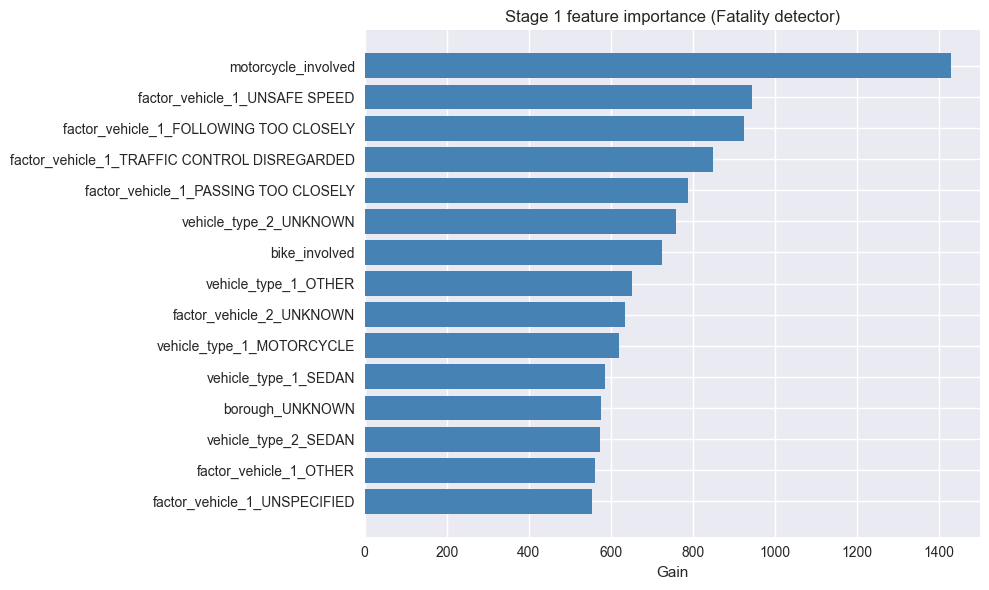

                                                     gain
motorcycle_involved                           1428.897583
factor_vehicle_1_UNSAFE SPEED                  944.514343
factor_vehicle_1_FOLLOWING TOO CLOSELY         926.023254
factor_vehicle_1_TRAFFIC CONTROL DISREGARDED   848.167297
factor_vehicle_1_PASSING TOO CLOSELY           787.525513
vehicle_type_2_UNKNOWN                         759.621216
bike_involved                                  723.971619
vehicle_type_1_OTHER                           652.649658
factor_vehicle_2_UNKNOWN                       635.416077
vehicle_type_1_MOTORCYCLE                      620.181213
vehicle_type_1_SEDAN                           587.000183
borough_UNKNOWN                                577.220398
vehicle_type_2_SEDAN                           573.224304
factor_vehicle_1_OTHER                         561.280579
factor_vehicle_1_UNSPECIFIED                   554.319763

=== Stage 2: No Injury vs. Injury ===


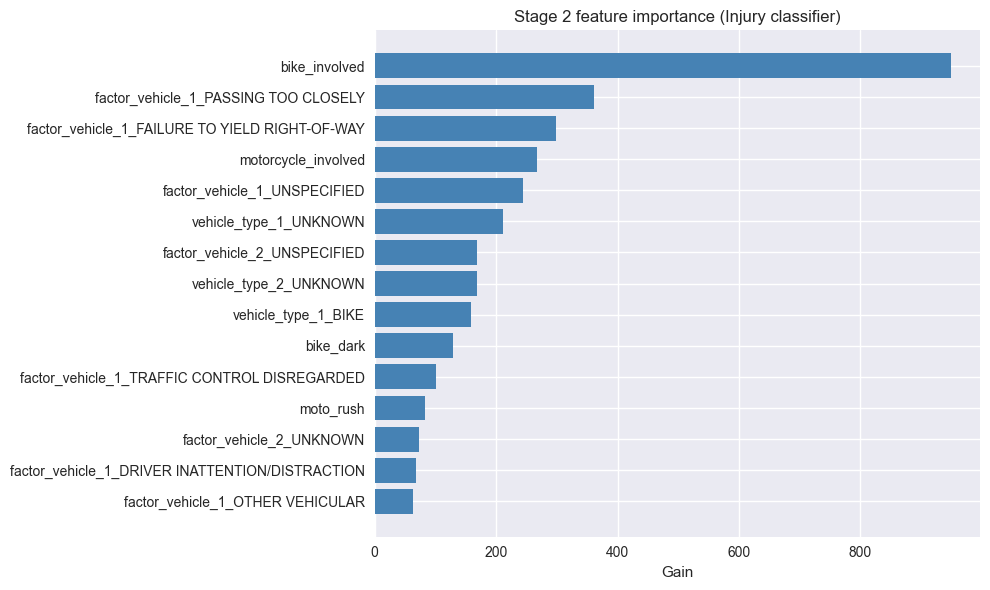

                                                       gain
bike_involved                                    949.752258
factor_vehicle_1_PASSING TOO CLOSELY             360.932220
factor_vehicle_1_FAILURE TO YIELD RIGHT-OF-WAY   298.112488
motorcycle_involved                              266.907990
factor_vehicle_1_UNSPECIFIED                     243.509308
vehicle_type_1_UNKNOWN                           210.917419
factor_vehicle_2_UNSPECIFIED                     168.139343
vehicle_type_2_UNKNOWN                           168.010132
vehicle_type_1_BIKE                              159.096588
bike_dark                                        128.654282
factor_vehicle_1_TRAFFIC CONTROL DISREGARDED     100.187492
moto_rush                                         82.279648
factor_vehicle_2_UNKNOWN                          73.610672
factor_vehicle_1_DRIVER INATTENTION/DISTRACTION   68.797173
factor_vehicle_1_OTHER VEHICULAR                  62.398418


In [16]:
def get_importance(model, title, top_n=15):
    raw  = model.get_booster().get_score(importance_type='gain')
    df_i = (pd.DataFrame.from_dict(raw, orient='index', columns=['gain'])
              .sort_values('gain', ascending=False)
              .head(top_n))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_i.index[::-1], df_i['gain'][::-1], color='steelblue')
    ax.set_xlabel('Gain'); ax.set_title(title)
    plt.tight_layout(); plt.show()
    return df_i

print('=== Stage 1: Fatality vs. Not-Fatality ===')
imp_s1 = get_importance(stage1, 'Stage 1 feature importance (Fatality detector)')
print(imp_s1.to_string())

print('\n=== Stage 2: No Injury vs. Injury ===')
imp_s2 = get_importance(stage2, 'Stage 2 feature importance (Injury classifier)')
print(imp_s2.to_string())

---
## 12. What the two stages learned differently

Comparing Stage 1 vs. Stage 2 feature importance reveals which signals are specific to fatal crashes versus injury crashes — useful for both model understanding and policy targeting.

In [17]:
s1_set = set(imp_s1.index)
s2_set = set(imp_s2.index)

print('Features in Stage 1 top-15 but NOT Stage 2 top-15 (Fatality-specific signals):')
for f in sorted(s1_set - s2_set):
    print(f'  {f}')

print('\nFeatures in Stage 2 top-15 but NOT Stage 1 top-15 (Injury-specific signals):')
for f in sorted(s2_set - s1_set):
    print(f'  {f}')

print('\nFeatures in both top-15 (shared signals):')
for f in sorted(s1_set & s2_set):
    print(f'  {f}')

Features in Stage 1 top-15 but NOT Stage 2 top-15 (Fatality-specific signals):
  borough_UNKNOWN
  factor_vehicle_1_FOLLOWING TOO CLOSELY
  factor_vehicle_1_OTHER
  factor_vehicle_1_UNSAFE SPEED
  vehicle_type_1_MOTORCYCLE
  vehicle_type_1_OTHER
  vehicle_type_1_SEDAN
  vehicle_type_2_SEDAN

Features in Stage 2 top-15 but NOT Stage 1 top-15 (Injury-specific signals):
  bike_dark
  factor_vehicle_1_DRIVER INATTENTION/DISTRACTION
  factor_vehicle_1_FAILURE TO YIELD RIGHT-OF-WAY
  factor_vehicle_1_OTHER VEHICULAR
  factor_vehicle_2_UNSPECIFIED
  moto_rush
  vehicle_type_1_BIKE
  vehicle_type_1_UNKNOWN

Features in both top-15 (shared signals):
  bike_involved
  factor_vehicle_1_PASSING TOO CLOSELY
  factor_vehicle_1_TRAFFIC CONTROL DISREGARDED
  factor_vehicle_1_UNSPECIFIED
  factor_vehicle_2_UNKNOWN
  motorcycle_involved
  vehicle_type_2_UNKNOWN
